In [1]:
!pip install tensorflow -q

In [2]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import math
import cv2


# Keras and Tensorflow modules
import keras
import tensorflow as tf # Keep for tf.keras.utils.set_random_seed, tf.math.confusion_matrix, tf.expand_dims, tf.repeat, tf.keras.metrics.Metric, tf.keras.metrics.F1Score, tf.keras.backend.clear_session, tf.keras.utils.register_keras_serializable

# Keras imports based on user request and notebook functionality
from keras import layers
from keras.applications import MobileNetV2
from keras.layers import Dense, Flatten # Specific layers requested by user
from keras.optimizers import Adam

# Additional necessary Keras imports for existing notebook functionality
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Crucial for data loading
from keras.models import Sequential, Model # Crucial for model building (Sequential, Model)
from keras.optimizers import SGD # SGD was also in the original optimizers import

# Removed: Dropout, Conv2D, MaxPooling2D, BatchNormalization, Lambda, Input from keras.layers as they are not explicitly used in this notebook's model definition.
# Removed: from keras.applications.vgg16 import VGG16 as MobileNetV2 is now the focus.


from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# Display images using OpenCV
from google.colab.patches import cv2_imshow

#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')


# Custom F1ScoreMetric class to handle 1D y_true from ImageDataGenerator
class F1ScoreMetric(tf.keras.metrics.Metric):
    def __init__(self, name='f1_score', threshold=0.5, **kwargs):
        super(F1ScoreMetric, self).__init__(name=name, **kwargs)
        # For binary classification with model output (batch_size, 1) and y_true (batch_size,)
        # Use num_classes=2 and average='binary' for binary classification.
        # This allows F1Score to internally handle the 1D y_true and 1D y_pred (converted from probabilities).
        self.f1_score_metric = tf.keras.metrics.F1Score(
            average='weighted', # Changed from 'binary' to 'weighted' for binary classification
            threshold=threshold
            # Removed num_classes=2 as it's not a valid argument for tf.keras.metrics.F1Score in current TF versions
        )

    def update_state(self, y_true, y_pred, sample_weight=None):
        # ImageDataGenerator with class_mode='binary' yields y_true as (batch_size,)
        # Model output Dense(1, sigmoid) yields y_pred as (batch_size, 1)
        # Explicitly expanding dimensions of y_true to (batch_size, 1) to match y_pred
        y_true = tf.expand_dims(y_true, axis=-1)
        self.f1_score_metric.update_state(y_true, y_pred, sample_weight)

    def result(self):
        return self.f1_score_metric.result()

    def reset_states(self):
        self.f1_score_metric.reset_states()

# Define the custom layer for Grayscale to RGB conversion
@keras.saving.register_keras_serializable(package="Custom")
class GrayscaleToRGB(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, inputs):
        # Repeat the single channel 3 times to simulate RGB channels
        # Assumes input shape is (batch, height, width, 1)
        return keras.ops.repeat(inputs, repeats=3, axis=-1)

    def get_config(self):
        # Implement get_config to enable serialization of the custom layer
        return super().get_config()

In [3]:
tf.keras.utils.set_random_seed(42)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Define the base directory for the MonReader dataset
base_dir = '/content/drive/MyDrive/MLProjects/MonReader/images/'

# Create ImageDataGenerator for data augmentation and preprocessing
# Rescale pixel values to [0, 1] for normalization
train_datagen = ImageDataGenerator(rescale=1./255,
                                 rotation_range=20,
                                 width_shift_range=0.2,
                                 height_shift_range=0.2,
                                 shear_range=0.2,
                                 zoom_range=0.2,
                                 horizontal_flip=True,
                                 fill_mode='nearest')

# Note: Data augmentation should generally only be applied to the training set.
# For validation and test sets, only rescaling is typically applied.
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Load images from directories using flow_from_directory
# target_size should match the input size expected by the model (e.g., 200x200 for VGG16 base)
# class_mode='binary' is used for two classes (flip/not_flip)
# batch_size as defined in the original notebook for consistency (e.g., 32)

image_height, image_width = 200, 200 # Adjust if your images have a different size
batch_size = 32

train_generator = train_datagen.flow_from_directory(
    os.path.join(base_dir, 'train'),
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='binary',
    color_mode='grayscale', # Added this line for grayscale conversion
    seed=42
)


test_generator = val_test_datagen.flow_from_directory(
    os.path.join(base_dir, 'test'),
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='binary',
    color_mode='grayscale', # Added this line for grayscale conversion
    seed=42,
    shuffle=False # Keep data in order for consistent evaluation
)

print("Data generators created successfully.")
print(f"Number of images in the training class: {train_generator.samples}")
print(f"Number of images in the test class: {test_generator.samples}")
print(f"Training classes: {train_generator.class_indices}")
print(f"Test classes: {test_generator.class_indices}")

Found 2392 images belonging to 2 classes.
Found 597 images belonging to 2 classes.
Data generators created successfully.
Number of images in the training class: 2392
Number of images in the test class: 597
Training classes: {'flip': 0, 'notflip': 1}
Test classes: {'flip': 0, 'notflip': 1}


In [6]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(model, predictors, target, is_multiclass=False):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable (pandas Series)
    is_multiclass: True if the model outputs probabilities for multiple classes (e.g., softmax),
                   False if it outputs a single probability for binary classification (e.g., sigmoid).
    """

    if is_multiclass:
        # For multi-class (softmax output), get class with highest probability
        predictions_raw = model.predict(predictors)
        pred_labels = np.argmax(predictions_raw, axis=1)
    else:
        # For binary (sigmoid output), threshold at 0.5
        pred_labels = (model.predict(predictors).reshape(-1) > 0.5).astype(int)

    target_np = target.to_numpy().reshape(-1)

    acc = accuracy_score(target_np, pred_labels)  # to compute Accuracy
    recall = recall_score(target_np, pred_labels, average='weighted')  # to compute Recall
    precision = precision_score(target_np, pred_labels, average='weighted')  # to compute Precision
    f1 = f1_score(target_np, pred_labels, average='weighted')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,}, index=[0],)

    return df_perf

In [7]:
def plot_confusion_matrix(model, predictors, target, is_multiclass=False):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable (pandas Series)
    is_multiclass: True if the model outputs probabilities for multiple classes (e.g., softmax),
                   False if it outputs a single probability for binary classification (e.g., sigmoid).
    """

    if is_multiclass:
        predictions_raw = model.predict(predictors)
        pred_labels = np.argmax(predictions_raw, axis=1)
    else:
        pred_labels = (model.predict(predictors).reshape(-1) > 0.5).astype(int)

    target_np = target.to_numpy().reshape(-1)

    # Plotting the Confusion Matrix using tf.math.confusion_matrix
    confusion_mtx = tf.math.confusion_matrix(target_np, pred_labels)
    f, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        confusion_mtx,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )
    plt.title(f"Confusion Matrix for {model.name if hasattr(model, 'name') else 'Model'}")
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

In [8]:
# GrayscaleToRGB is now defined in the main import cell

# Clear any previous model state to prevent naming conflicts
tf.keras.backend.clear_session()

# 1. Load the pre-trained MobileNetV2 model
# input_shape expects 3 channels, so we'll handle grayscale conversion before this.
mobilenet_model_base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(image_height, image_width, 3), name='mobilenetv2_base')

# 2. Freeze the convolutional layers of MobileNetV2
for layer in mobilenet_model_base.layers:
    layer.trainable = False

# 3. Build Model 7 (MobileNetV2 Base with a simple classification head)
model_7 = Sequential(name='MobileNetV2_Base_Model')

# Add the custom GrayscaleToRGB layer
model_7.add(GrayscaleToRGB(input_shape=(image_height, image_width, 1), name='grayscale_to_rgb_conversion'))

# Add the frozen MobileNetV2 base model
model_7.add(mobilenet_model_base)

# Flatten the output for the dense layers
model_7.add(Flatten())

# Add a simple dense output layer for binary classification
model_7.add(Dense(1, activation='sigmoid'))

print("MobileNetV2 base model and custom head defined.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
MobileNetV2 base model and custom head defined.


In [11]:
opt = Adam(learning_rate=0.001)
model_7.compile(optimizer=opt, loss=keras.losses.BinaryCrossentropy(), metrics=["accuracy", "Recall", "Precision"])
print("Model 7 compiled successfully.")

Model 7 compiled successfully.


In [12]:
print("\n--- Model 7 (MobileNetV2 Base) Summary ---")
model_7.summary()


--- Model 7 (MobileNetV2 Base) Summary ---


Model: "MobileNetV2_Base_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ grayscale_to_rgb_conversion     │ (None, 200, 200, 3)    │             0 │
│ (GrayscaleToRGB)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_base (Functional)   │ (None, 7, 7, 1280)     │     2,257,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        62,721 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,320,705 (8.85 MB)

 Trainable params: 62,721 (245.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [13]:
print("\n--- Training Model MobileNet")
epochs = 10 #define the epochs, re-defining it here for local scope
history_7 = model_7.fit(
    train_generator,
    epochs=epochs,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=test_generator,
    validation_steps=test_generator.samples // test_generator.batch_size,
    verbose=1
)


--- Training Model MobileNet
Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1430s 19s/step - Precision: 0.7362 - Recall: 0.7387 - accuracy: 0.7297 - loss: 1.3158 - val_Precision: 0.8835 - val_Recall: 0.8217 - val_accuracy: 0.8576 - val_loss: 0.5157
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 47s 623ms/step - Precision: 0.8889 - Recall: 0.9412 - accuracy: 0.9062 - loss: 0.3105 - val_Precision: 0.8880 - val_Recall: 0.7483 - val_accuracy: 0.8281 - val_loss: 0.5822
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step - Precision: 0.8421 - Recall: 0.8358 - accuracy: 0.8352 - loss: 0.5448 - val_Precision: 0.7636 - val_Recall: 0.9825 - val_accuracy: 0.8403 - val_loss: 0.6891
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 41s 543ms/step - Precision: 0.7826 - Recall: 1.0000 - accuracy: 0.8438 - loss: 0.8878 - val_Precision: 0.7720 - val_Recall: 0.9825 - val_accuracy: 0.8472 - val_loss: 0.6700
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 175s 2s/step - Precision: 0.8600 - Recall: 0.8628 - accuracy: 0.8576 - loss: 0.4933 - val_

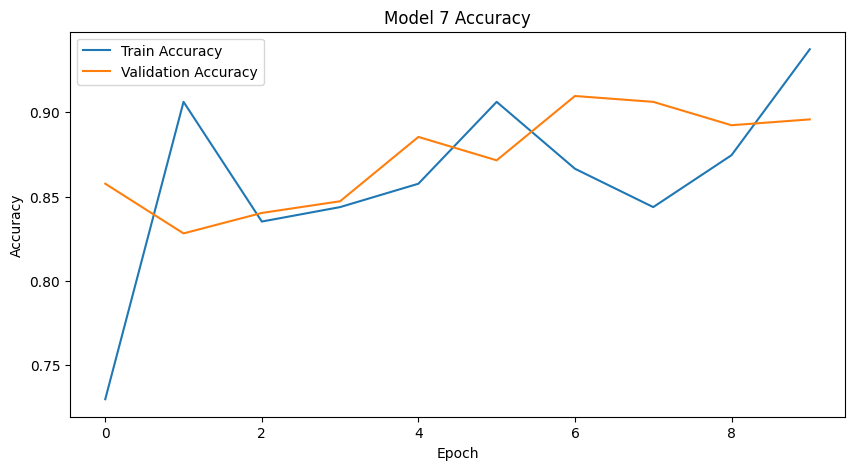

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(history_7.history['accuracy'], label='Train Accuracy')
plt.plot(history_7.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model 7 Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

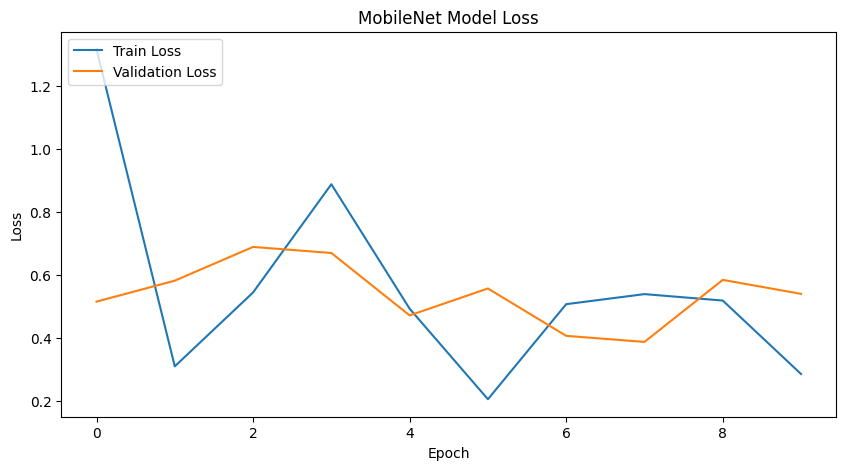

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(history_7.history['loss'], label='Train Loss')
plt.plot(history_7.history['val_loss'], label='Validation Loss')
plt.title('MobileNet Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()


--- Extracting Training Data for Evaluation ---
Found 2392 images belonging to 2 classes.

--- MobileNet: Training Performance ---
75/75 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step
   Accuracy    Recall  Precision  F1 Score
0  0.895067  0.895067   0.902714  0.894792
75/75 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step


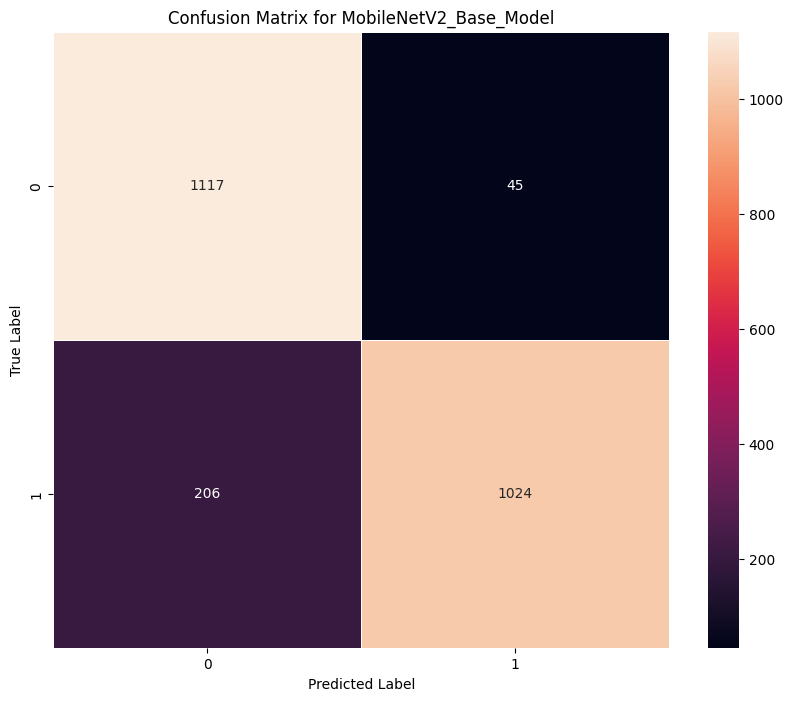


--- Extracting Test Data for Evaluation ---

--- MobileNet: Test Performance ---
19/19 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step
   Accuracy    Recall  Precision  F1 Score
0  0.897822  0.897822   0.902442  0.897698
19/19 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step


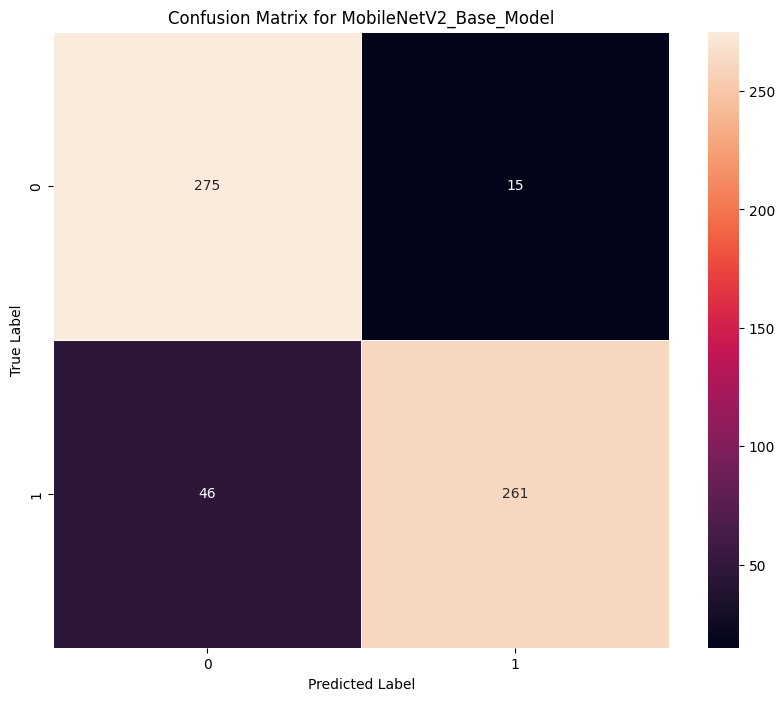

In [16]:
print("\n--- Extracting Training Data for Evaluation ---")
# Create a generator for the training set without augmentation for consistent evaluation
train_eval_datagen = ImageDataGenerator(rescale=1./255)

train_eval_generator = train_eval_datagen.flow_from_directory(
    os.path.join(base_dir, 'train'),
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='binary',
    color_mode='grayscale',
    seed=42, # Use the same seed for consistency
    shuffle=False # IMPORTANT: Do not shuffle for evaluation to ensure consistent order
)

# Extract all images and labels from this new generator
num_train_samples = train_eval_generator.samples
X_train_extracted = []
y_train_extracted = []

train_eval_generator.reset() # Ensure it starts from the beginning

for _ in range(num_train_samples // batch_size + (1 if num_train_samples % batch_size > 0 else 0)):
    batch_X, batch_y = train_eval_generator.__next__() # Corrected: Use __next__()
    X_train_extracted.append(batch_X)
    y_train_extracted.append(batch_y)

X_train_normalized = np.concatenate(X_train_extracted, axis=0)
y_train = pd.Series(np.concatenate(y_train_extracted, axis=0)) # Convert to Pandas Series as expected by functions

print("\n--- MobileNet: Training Performance ---")
model_7_train_perf = model_performance_classification(model_7, X_train_normalized, y_train)
print(model_7_train_perf)
plot_confusion_matrix(model_7, X_train_normalized, y_train)

print("\n--- Extracting Test Data for Evaluation ---")
# Use the already defined test_generator (which is suitable for evaluation)
num_test_samples = test_generator.samples
X_test_extracted = []
y_test_extracted = []

test_generator.reset() # Ensure it starts from the beginning

for _ in range(num_test_samples // batch_size + (1 if num_test_samples % batch_size > 0 else 0)):
    batch_X, batch_y = test_generator.__next__() # Corrected: Use __next__()
    X_test_extracted.append(batch_X)
    y_test_extracted.append(batch_y)

X_test_normalized = np.concatenate(X_test_extracted, axis=0)
y_test = pd.Series(np.concatenate(y_test_extracted, axis=0))

print("\n--- MobileNet: Test Performance ---")
model_7_test_perf = model_performance_classification(model_7, X_test_normalized, y_test)
print(model_7_test_perf)
plot_confusion_matrix(model_7, X_test_normalized, y_test)


# Deployment

In [15]:
# Create a folder for storing the files needed for web app deployment
os.makedirs("backend_files", exist_ok=True)


In [16]:
# Define the file path to save the trained Keras model in native Keras format
saved_model_filepath = "backend_files/monreader_saved_model"

In [17]:
import tensorflow as tf # Ensure tf is imported for saving Keras models
from keras import layers # Unified import
from keras.optimizers import Adam # Use keras.optimizers.Adam

# Define the custom layer for Grayscale to RGB conversion (must be available during loading)
@keras.saving.register_keras_serializable(package="Custom")
class GrayscaleToRGB(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, inputs):
        return keras.ops.repeat(inputs, repeats=3, axis=-1)

    def get_config(self):
        return super().get_config()

# Re-compile Model 7 to ensure latest changes are registered before saving
opt = Adam(learning_rate=0.001)
model_7.compile(optimizer=opt, loss=keras.losses.BinaryCrossentropy(), metrics=["accuracy", "Recall", "Precision"])

# Export the model using Keras's export method (TensorFlow SavedModel format)
model_7.export(saved_model_filepath)

print(f"Keras model exported successfully in SavedModel format to {saved_model_filepath}")

Saved artifact at 'backend_files/monreader_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 200, 200, 1), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  137142618535504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137142618536080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137142618536464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137142618537808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137142618537616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137142618535888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137142601974800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137142601975760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137142601975376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137142601974992: TensorSpec(shape=(), dtype=tf.resource, name

In [18]:
import tensorflow as tf
import keras # Ensure keras is imported

# Load the Keras model using TFSMLayer for SavedModel format in Keras 3
# The 'serve' endpoint is the default endpoint for models exported with model.export()
saved_model = keras.layers.TFSMLayer(saved_model_filepath, call_endpoint='serve')

# Confirm the model is loaded
print("Keras model loaded successfully using TFSMLayer.")

Keras model loaded successfully using TFSMLayer.


In [19]:
saved_model

<TFSMLayer name=tfsm_layer, built=True>

In [20]:
import tensorflow as tf
# Call the TFSMLayer directly for prediction
predictions = saved_model(X_test_normalized)
# If you need the raw numpy output:
print(predictions.numpy())

[[1.50163781e-09]
 [1.92314900e-13]
 [1.21357849e-14]
 [2.64104767e-16]
 [1.09852363e-05]
 [9.52961922e-01]
 [6.82651222e-01]
 [1.37952593e-05]
 [2.74428421e-05]
 [1.80984417e-03]
 [2.99373914e-05]
 [3.86451075e-06]
 [2.84744805e-04]
 [9.01848078e-01]
 [3.39307666e-01]
 [6.60969723e-09]
 [2.60107088e-18]
 [1.92143480e-12]
 [1.86760887e-03]
 [2.82661131e-05]
 [3.49594557e-05]
 [1.79841288e-06]
 [8.35173890e-17]
 [5.40792156e-18]
 [8.03567294e-19]
 [5.38548535e-13]
 [2.45412055e-04]
 [1.96286669e-06]
 [1.48183863e-12]
 [3.06085724e-07]
 [1.64416982e-04]
 [3.07797848e-07]
 [7.11048789e-11]
 [3.88475087e-13]
 [5.88572635e-10]
 [4.61148769e-01]
 [1.30112426e-06]
 [5.38844468e-13]
 [5.99330141e-10]
 [7.50161416e-05]
 [7.10670943e-13]
 [1.16830872e-12]
 [2.27462389e-02]
 [2.15260219e-03]
 [1.32281496e-03]
 [2.33489031e-12]
 [1.41805048e-08]
 [1.25237890e-02]
 [4.99926465e-08]
 [2.46722109e-09]
 [4.30611796e-12]
 [6.84981956e-07]
 [1.38383394e-03]
 [1.07248903e-04]
 [9.94872835e-07]
 [2.702087

In [96]:
"""
Run this cell in Colab to reconvert the model WITHOUT quantization.
Quantization produces FULLY_CONNECTED op v12 which causes the runtime error.
"""
import tensorflow as tf

saved_model_filepath = "backend_files/monreader_saved_model"
tflite_output_path   = "backend_files/monreader.tflite"

converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_filepath)
# NO optimizations — keeps op versions compatible with the runtime
tflite_model = converter.convert()

with open(tflite_output_path, "wb") as f:
    f.write(tflite_model)

size_mb = len(tflite_model) / 1_000_000
print(f"Saved: {tflite_output_path} ({size_mb:.1f} MB)")

# Verify it loads cleanly before uploading
interpreter = tf.lite.Interpreter(model_path=tflite_output_path)
interpreter.allocate_tensors()
inp = interpreter.get_input_details()
out = interpreter.get_output_details()
print(f"Input : {inp[0]['shape']} {inp[0]['dtype']}")
print(f"Output: {out[0]['shape']} {out[0]['dtype']}")
print("Conversion OK — ready to upload")

Saved: backend_files/monreader.tflite (9.1 MB)
Input : [  1 200 200   1] <class 'numpy.float32'>
Output: [1 1] <class 'numpy.float32'>
Conversion OK — ready to upload


# Deployment backend

In [97]:
%%writefile backend_files/app.py

import numpy as np
from flask import Flask, request, jsonify
from flask_cors import CORS
from werkzeug.middleware.proxy_fix import ProxyFix
import cv2
import os
import logging

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

TFLITE_MODEL_PATH = os.path.join(os.path.dirname(os.path.abspath(__file__)), "monreader.tflite")
logging.info(f"Model path : {TFLITE_MODEL_PATH}")
logging.info(f"File exists: {os.path.exists(TFLITE_MODEL_PATH)}")

# tensorflow-cpu matches the TF version used to export the model (2.16.1)
# and starts in ~3s on CPU — fast enough to pass HF's health check
import tensorflow as tf
logging.info(f"TF version: {tf.__version__}")

logging.info("Loading TFLite model...")
interpreter = tf.lite.Interpreter(model_path=TFLITE_MODEL_PATH)
interpreter.allocate_tensors()
input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()
logging.info(f"Model loaded OK. Input: {input_details[0]['shape']} Output: {output_details[0]['shape']}")

app = Flask(__name__)
app.config['MAX_CONTENT_LENGTH'] = 50 * 1024 * 1024
app.wsgi_app = ProxyFix(app.wsgi_app, x_for=1, x_proto=1, x_host=1, x_prefix=1)
CORS(app)


@app.route("/", methods=["GET"])
def home():
    return jsonify({"status": "ok", "service": "MonReader page-flip predictor"})


@app.route("/v1/predict", methods=["POST", "OPTIONS"])
def predict_flip():
    if request.method == "OPTIONS":
        return jsonify({"status": "ok"}), 200

    if "image" not in request.files:
        return jsonify({"error": "No image file provided. Send multipart/form-data with key 'image'."}), 400

    file = request.files["image"]
    if file.filename == "":
        return jsonify({"error": "No selected image file"}), 400

    try:
        image_data   = file.read()
        np_img       = np.frombuffer(image_data, np.uint8)
        img          = cv2.imdecode(np_img, cv2.IMREAD_GRAYSCALE)

        if img is None:
            return jsonify({"error": "Could not decode image. Ensure the file is a valid JPG/PNG."}), 400

        img_resized  = cv2.resize(img, (200, 200))
        img_norm     = (img_resized / 255.0).astype(np.float32)
        input_tensor = img_norm[np.newaxis, :, :, np.newaxis]  # (1, 200, 200, 1)

        interpreter.set_tensor(input_details[0]['index'], input_tensor)
        interpreter.invoke()
        prediction_score = float(interpreter.get_tensor(output_details[0]['index'])[0][0])

        predicted_label = "flip" if prediction_score < 0.5 else "notflip"
        logging.info(f"Score: {prediction_score:.4f} -> {predicted_label}")

        return jsonify({
            "status": "success",
            "prediction_score": prediction_score,
            "prediction": predicted_label
        })

    except Exception as e:
        logging.error(f"Prediction error: {e}", exc_info=True)
        return jsonify({"error": f"Internal server error: {str(e)}"}), 500


if __name__ == "__main__":
    app.run(host="0.0.0.0", port=7860)



Overwriting backend_files/app.py


## requirements.txt

In [92]:
%%writefile backend_files/requirements.txt
flask==2.3.2
werkzeug==2.3.7
gunicorn==22.0.0
tensorflow-cpu==2.16.1
opencv-python-headless==4.10.0.84
numpy==1.26.4
pillow
flask-cors



Overwriting backend_files/requirements.txt


In [94]:
%%writefile backend_files/Dockerfile
FROM python:3.10-slim

WORKDIR /app

RUN apt-get update && apt-get install -y --no-install-recommends \
    libglib2.0-0 \
    libgl1 \
    && rm -rf /var/lib/apt/lists/*

COPY requirements.txt .
RUN pip install --upgrade pip
RUN pip install --no-cache-dir -r requirements.txt

COPY monreader.tflite .
COPY app.py .

EXPOSE 7860

# --timeout 120 gives tensorflow-cpu enough time to import on first worker boot
CMD ["gunicorn", "-b", "0.0.0.0:7860", "--timeout", "120", "--workers", "1", "--preload", "app:app"]




Overwriting backend_files/Dockerfile


In [81]:
%%writefile backend_files/README.md
---
title: MonReader Backend
emoji: 📖
colorFrom: blue
colorTo: green
sdk: docker
app_port: 7860
pinned: false
---

MonReader page-flip detection backend API.


Overwriting backend_files/README.md


In [ ]:
# Import the login function from the huggingface_hub library
from huggingface_hub import login

# Login to your Hugging Face account using your access token
# Replace "YOUR_HUGGINGFACE_TOKEN" with your actual token
#login(token="YOUR_HUGGINGFACE_TOKEN")  # You can get your token from https://huggingface.co/settings/tokens
login(token="") #define your Hugging Face access token

# Import the create_repo function from the huggingface_hub library
from huggingface_hub import create_repo

In [82]:
try:
    create_repo("monreader",  #define the name of your Hugging Face space
        repo_type="space",  # Specify the repository type as "space"
        space_sdk="docker",  # Specify the space SDK as "docker"
        private=False  # Set to True if you want the space to be private
    )
except Exception as e:
    # Handle potential errors during repository creation
    if "RepositoryAlreadyExistsError" in str(e):
        print("Repository already exists. Skipping creation.")
    else:
        print(f"Error creating repository: {e}")

Error creating repository: Client error '409 Conflict' for url 'https://huggingface.co/api/repos/create' (Request ID: Root=1-6a2cb750-2bbb7da37c7ffd424b84bb05;5d10f5a1-6dee-475e-b259-072b1e2ac51a)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/409

You already created this space repo: dcsamuel/monreader


In [ ]:
access_key = ""  # define your Hugging Face access token
repo_id = "ur_repo/monreader"  #define your Hugging Face repo_id

# Login to Hugging Face platform with the access token
login(token=access_key)

# Initialize the API
from huggingface_hub import HfApi
api = HfApi()

# Upload Streamlit app files stored in the folder called deployment_files
api.upload_folder(
    folder_path="backend_files",  # Local folder path in azureml
    path_in_repo=".", # Uploads contents of backend_files to the root of the repo
    repo_id=repo_id,  # Hugging face space id
    repo_type="space",  # Hugging face repo type "space"
    delete_patterns="*" # Force upload by deleting all previous content in the target directory
)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...aved_model/saved_model.pb: 100%|##########| 1.68MB / 1.68MB            

  ...aved_model/fingerprint.pb: 100%|##########|  96.0B /  96.0B            

  ...nd_files/monreader.tflite:   8%|7         |  709kB / 9.11MB            

  ...ables.data-00000-of-00001: 100%|##########| 18.6MB / 18.6MB            

CommitInfo(commit_url='https://huggingface.co/spaces/dcsamuel/monreader/commit/5a6173630edb6b3ecd105802bc59387ea88ae3ed', commit_message='Upload folder using huggingface_hub', commit_description='', oid='5a6173630edb6b3ecd105802bc59387ea88ae3ed', pr_url=None, repo_url=RepoUrl('https://huggingface.co/spaces/dcsamuel/monreader', endpoint='https://huggingface.co', repo_type='space', repo_id='dcsamuel/monreader'), pr_revision=None, pr_num=None)

## frontend

In [71]:
# Create a folder for storing the files needed for frontend UI deployment
os.makedirs("frontend_files", exist_ok=True)

In [ ]:
%%writefile frontend_files/app.py
import streamlit as st
import os

st.set_page_config(layout="centered", page_title="MonReader", page_icon="📖")

BACKEND_URL = os.getenv("MONREADER_BACKEND_URL", "https://uruser-monreader.hf.space/v1/predict")

st.markdown("""
<style>
[data-testid="stAppViewContainer"],
[data-testid="stMain"],
[data-testid="block-container"] {
    background: #f0f0f0 !important;
    padding: 0 !important;
}
[data-testid="stHeader"], #MainMenu, footer, header { display: none !important; }
</style>
""", unsafe_allow_html=True)

st.components.v1.html(f"""
<!DOCTYPE html>
<html>
<head>
<meta name="viewport" content="width=device-width, initial-scale=1">
<style>
  * {{ box-sizing: border-box; margin: 0; padding: 0; }}

  body {{
    background: #f0f0f0;
    display: flex;
    justify-content: center;
    align-items: flex-start;
    padding: 32px 16px 48px;
    font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', sans-serif;
  }}

  /* ── Phone shell ───────────────────────────────── */
  .phone {{
    width: 340px;
    background: #0f0f1a;
    border-radius: 52px;
    border: 7px solid #2a2a3d;
    box-shadow:
      0 0 0 2px #111,
      0 40px 100px rgba(0,0,0,0.3),
      inset 0 0 0 1px #333;
    position: relative;
    display: flex;
    flex-direction: column;
  }}

  /* Notch */
  .phone::before {{
    content: '';
    position: absolute;
    top: 0; left: 50%;
    transform: translateX(-50%);
    width: 130px; height: 30px;
    background: #0f0f1a;
    border-radius: 0 0 22px 22px;
    border: 6px solid #2a2a3d;
    border-top: none;
    z-index: 10;
  }}

  /* Power button */
  .phone::after {{
    content: '';
    position: absolute;
    top: 110px; right: -10px;
    width: 4px; height: 56px;
    background: #2a2a3d;
    border-radius: 0 3px 3px 0;
    box-shadow: 0 76px 0 0 #2a2a3d;
  }}

  /* Volume buttons */
  .vol {{
    position: absolute;
    top: 110px; left: -10px;
    width: 4px; height: 40px;
    background: #2a2a3d;
    border-radius: 3px 0 0 3px;
    box-shadow: 0 52px 0 0 #2a2a3d;
  }}

  /* Status bar — fixed at top, never scrolls */
  .status-bar {{
    flex-shrink: 0;
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 44px 22px 10px;
    color: #ccc;
    font-size: 11px;
    font-weight: 600;
  }}

  /* Scrollable screen area */
  .screen {{
    flex: 1;
    overflow-y: auto;
    overflow-x: hidden;
    padding: 0 16px 16px;
    /* hide scrollbar visually but keep it functional */
    scrollbar-width: none;        /* Firefox */
    -ms-overflow-style: none;     /* IE */
  }}
  .screen::-webkit-scrollbar {{ display: none; }} /* Chrome/Safari */

  /* Scroll hint pill — shows when content overflows */
  .scroll-hint {{
    flex-shrink: 0;
    display: flex;
    align-items: center;
    justify-content: center;
    gap: 5px;
    padding: 6px 0 2px;
    color: #555;
    font-size: 10px;
  }}
  .scroll-hint .arrow {{
    width: 18px; height: 18px;
    border: 1.5px solid #444;
    border-radius: 50%;
    display: flex; align-items: center; justify-content: center;
    font-size: 9px;
    animation: bounce 1.4s ease-in-out infinite;
  }}
  @keyframes bounce {{
    0%,100% {{ transform: translateY(0);   opacity:.5; }}
    50%      {{ transform: translateY(3px); opacity:1;  }}
  }}

  /* Home bar */
  .home-bar {{
    flex-shrink: 0;
    width: 90px; height: 4px;
    background: #333;
    border-radius: 3px;
    margin: 8px auto 20px;
  }}

  /* ── App header ────────────────────────────────── */
  .app-header {{
    background: linear-gradient(135deg, #6c63ff, #3b3566);
    border-radius: 20px;
    padding: 16px;
    text-align: center;
    margin-bottom: 16px;
  }}
  .app-header h1 {{ color:#fff; font-size:18px; font-weight:700; margin-bottom:2px; }}
  .app-header p  {{ color:rgba(255,255,255,0.7); font-size:11px; }}

  /* ── Upload area ───────────────────────────────── */
  .upload-area {{
    border: 2px dashed #6c63ff;
    border-radius: 16px;
    background: rgba(108,99,255,0.08);
    padding: 28px 12px;
    text-align: center;
    cursor: pointer;
    transition: background 0.2s;
    margin-bottom: 14px;
    position: relative;
  }}
  .upload-area:hover {{ background: rgba(108,99,255,0.15); }}
  .upload-area input {{
    position: absolute; inset: 0;
    opacity: 0; cursor: pointer; width: 100%; height: 100%;
  }}
  .upload-area .icon {{ font-size: 32px; margin-bottom: 8px; }}
  .upload-area p    {{ color: #888; font-size: 12px; }}
  .upload-area .hint {{ color: #555; font-size: 10px; margin-top: 4px; }}

  /* ── Preview image ─────────────────────────────── */
  #preview-wrap {{
    display: none;
    border-radius: 14px;
    overflow: hidden;
    margin-bottom: 14px;
    position: relative;
  }}
  #preview-wrap img {{
    width: 100%;
    display: block;
    border-radius: 14px;
  }}
  .preview-badge {{
    position: absolute; bottom: 8px; right: 8px;
    background: rgba(0,0,0,0.6);
    color: #fff; font-size: 10px;
    padding: 3px 8px; border-radius: 20px;
  }}

  /* ── Predict button ────────────────────────────── */
  .btn-predict {{
    width: 100%; padding: 13px;
    background: linear-gradient(135deg, #6c63ff, #4b44cc);
    border: none; border-radius: 14px;
    color: #fff; font-size: 15px; font-weight: 600;
    cursor: pointer; margin-bottom: 10px;
    letter-spacing: 0.3px; transition: opacity 0.2s;
  }}
  .btn-predict:hover  {{ opacity: 0.88; }}
  .btn-predict:active {{ opacity: 0.75; }}
  .btn-predict:disabled {{
    background: #2a2a3d; color: #555;
    cursor: not-allowed; opacity: 1;
  }}

  /* ── Reset button ──────────────────────────────── */
  .btn-reset {{
    width: 100%; padding: 11px;
    background: transparent;
    border: 1.5px solid #3a3a5c;
    border-radius: 14px; color: #777;
    font-size: 13px; cursor: pointer;
    transition: border-color 0.2s, color 0.2s;
    margin-bottom: 36px;
  }}
  .btn-reset:hover {{ border-color: #6c63ff; color: #aaa; }}

  /* ── Spinner ───────────────────────────────────── */
  .spinner-wrap {{
    display: none; text-align: center;
    padding: 12px 0; color: #888; font-size: 12px;
  }}
  .spinner {{
    width: 28px; height: 28px;
    border: 3px solid #2a2a3d; border-top-color: #6c63ff;
    border-radius: 50%;
    animation: spin 0.8s linear infinite;
    margin: 0 auto 8px;
  }}
  @keyframes spin {{ to {{ transform: rotate(360deg); }} }}

  /* ── Result card ───────────────────────────────── */
  .result-card {{
    border-radius: 16px; padding: 16px;
    text-align: center; margin-bottom: 12px; display: none;
  }}
  .result-card.flip    {{ background:rgba(255,107,107,0.12); border:1px solid rgba(255,107,107,0.35); }}
  .result-card.notflip {{ background:rgba(81,207,102,0.12);  border:1px solid rgba(81,207,102,0.35); }}
  .result-icon  {{ font-size:34px; margin-bottom:6px; }}
  .result-label {{ font-size:20px; font-weight:700; margin-bottom:4px; }}
  .result-card.flip    .result-label {{ color:#ff6b6b; }}
  .result-card.notflip .result-label {{ color:#51cf66; }}
  .result-conf  {{ font-size:11px; color:#777; }}

  /* ── Error box ─────────────────────────────────── */
  .error-box {{
    display: none;
    background: rgba(255,107,107,0.1);
    border: 1px solid rgba(255,107,107,0.3);
    border-radius: 12px;
    padding: 10px 14px; color: #ff6b6b;
    font-size: 12px; text-align: center; margin-bottom: 10px;
  }}
</style>
</head>
<body>
<div class="phone">
  <div class="vol"></div>

  <!-- Fixed status bar -->
  <div class="status-bar">
    <span>9:41</span>
    <span>▲▲▲ &nbsp; 🔋</span>
  </div>

  <!-- Scrollable content -->
  <div class="screen" id="screen">

    <div class="app-header">
      <h1>📖 MonReader</h1>
      <p>Page-flip detection</p>
    </div>

    <div class="upload-area" id="upload-area">
      <input type="file" id="file-input" accept="image/jpeg,image/png,image/webp">
      <div class="icon">📷</div>
      <p>Tap to choose an image</p>
      <p class="hint">JPG, PNG or WebP</p>
    </div>

    <div id="preview-wrap">
      <img id="preview-img" src="" alt="preview">
      <div class="preview-badge" id="file-name"></div>
    </div>

    <div class="spinner-wrap" id="spinner">
      <div class="spinner"></div>
      <div>Analysing image…</div>
    </div>

    <div class="error-box" id="error-box"></div>

    <div class="result-card" id="result-card">
      <div class="result-icon"  id="result-icon"></div>
      <div class="result-label" id="result-label"></div>
      <div class="result-conf"  id="result-conf"></div>
    </div>

    <button class="btn-predict" id="btn-predict" disabled>Predict Page-Flip</button>
    <button class="btn-reset"   id="btn-reset"   style="display:none">↩ Reset / New image</button>

  </div><!-- /screen -->

  <!-- Scroll hint — hidden once user has scrolled or no overflow -->
  <div class="scroll-hint" id="scroll-hint" style="display:none">
    <div class="arrow">▼</div>
    <span>scroll for more</span>
    <div class="arrow">▼</div>
  </div>

  <div class="home-bar"></div>
</div><!-- /phone -->

<script>
const BACKEND = "{BACKEND_URL}";

const fileInput   = document.getElementById('file-input');
const uploadArea  = document.getElementById('upload-area');
const previewWrap = document.getElementById('preview-wrap');
const previewImg  = document.getElementById('preview-img');
const fileNameEl  = document.getElementById('file-name');
const spinner     = document.getElementById('spinner');
const errorBox    = document.getElementById('error-box');
const resultCard  = document.getElementById('result-card');
const resultIcon  = document.getElementById('result-icon');
const resultLabel = document.getElementById('result-label');
const resultConf  = document.getElementById('result-conf');
const btnPredict  = document.getElementById('btn-predict');
const btnReset    = document.getElementById('btn-reset');
const screen      = document.getElementById('screen');
const scrollHint  = document.getElementById('scroll-hint');

let selectedFile = null;

// Show scroll hint when content overflows, hide once user scrolls
function checkOverflow() {{
  if (screen.scrollHeight > screen.clientHeight + 10) {{
    scrollHint.style.display = 'flex';
  }} else {{
    scrollHint.style.display = 'none';
  }}
}}

screen.addEventListener('scroll', () => {{
  if (screen.scrollTop > 10) scrollHint.style.display = 'none';
}});

fileInput.addEventListener('change', (e) => {{
  const file = e.target.files[0];
  if (!file) return;
  selectedFile = file;

  const reader = new FileReader();
  reader.onload = (ev) => {{
    previewImg.src = ev.target.result;
    previewWrap.style.display = 'block';
    uploadArea.style.display  = 'none';
    fileNameEl.textContent    = file.name;
    btnPredict.disabled = false;
    setTimeout(checkOverflow, 100);
  }};
  reader.readAsDataURL(file);

  hide(resultCard); hide(errorBox); hide(btnReset);
  resultCard.className = 'result-card';
}});

btnPredict.addEventListener('click', async () => {{
  if (!selectedFile) return;

  btnPredict.disabled = true;
  show(spinner); hide(errorBox); hide(resultCard);
  setTimeout(checkOverflow, 50);

  const formData = new FormData();
  formData.append('image', selectedFile, selectedFile.name);

  try {{
    const resp = await fetch(BACKEND, {{ method: 'POST', body: formData }});
    const data = await resp.json();
    hide(spinner);

    if (!resp.ok || data.error) {{
      showError(data.error || 'Server error ' + resp.status);
      btnPredict.disabled = false;
      setTimeout(checkOverflow, 50);
      return;
    }}

    const pred   = data.prediction;
    const score  = data.prediction_score;
    const isFlip = pred === 'flip';
    const conf = isFlip ? (1 - score) : score;

    resultCard.className   = 'result-card ' + (isFlip ? 'flip' : 'notflip');
    resultIcon.textContent  = isFlip ? '📄🔄' : '📄✅';
    resultLabel.textContent = isFlip ? 'Page Flip' : 'Not a Flip';
    resultConf.textContent  = 'Confidence: ' + (conf * 100).toFixed(1) + '%';

    show(resultCard); show(btnReset);
    btnPredict.style.display = 'none';

    // Scroll result into view and check overflow
    setTimeout(() => {{
      resultCard.scrollIntoView({{ behavior: 'smooth', block: 'nearest' }});
      checkOverflow();
    }}, 100);

  }} catch (err) {{
    hide(spinner);
    showError('Could not reach backend. Check your connection.');
    btnPredict.disabled = false;
    setTimeout(checkOverflow, 50);
  }}
}});

btnReset.addEventListener('click', () => {{
  selectedFile = null;
  fileInput.value = '';
  previewImg.src  = '';
  previewWrap.style.display = 'none';
  uploadArea.style.display  = 'block';
  btnPredict.style.display  = 'block';
  btnPredict.disabled = true;
  hide(resultCard); hide(errorBox); hide(btnReset); hide(spinner);
  resultCard.className = 'result-card';
  screen.scrollTop = 0;
  setTimeout(checkOverflow, 50);
}});

function show(el) {{ el.style.display = 'block'; }}
function hide(el) {{ el.style.display = 'none';  }}
function showError(msg) {{ errorBox.textContent = msg; show(errorBox); }}

// Initial check
setTimeout(checkOverflow, 200);
</script>
</body>
</html>
""", height=900, scrolling=False)


Overwriting frontend_files/app.py


In [117]:
%%writefile frontend_files/requirements.txt
streamlit==1.33.0
opencv-python-headless==4.10.0.84
numpy==1.26.4
pillow
requests==2.31.0
huggingface_hub

Overwriting frontend_files/requirements.txt


In [118]:
%%writefile frontend_files/Dockerfile
FROM python:3.10-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY app.py .

EXPOSE 7860

ENV STREAMLIT_SERVER_HEADLESS=1
ENV STREAMLIT_BROWSER_GATHER_USAGE_STATS=false
ENV STREAMLIT_SERVER_ENABLE_CORS=false
ENV STREAMLIT_SERVER_ENABLE_XSRF_PROTECTION=false

CMD ["streamlit", "run", "app.py", "--server.port=7860", "--server.address=0.0.0.0"]


Overwriting frontend_files/Dockerfile


In [109]:
%%writefile frontend_files/README.md
---
title: MonReader
emoji: 📱
colorFrom: purple
colorTo: blue
sdk: docker
app_port: 7860
pinned: false
---
MonReader - Page flip prediction app.

Overwriting frontend_files/README.md


Now, let's upload the modified `frontend_files` to your Hugging Face Space. This will update your Streamlit application with the new image upload functionality.

In [76]:
try:
    create_repo("monreaderview",  #define the name of your Hugging Face space
        repo_type="space",  # Specify the repository type as "space"
        space_sdk="docker",  # Specify the space SDK as "docker"
        private=False  # Set to True if you want the space to be private
    )
except Exception as e:
    # Handle potential errors during repository creation
    if "RepositoryAlreadyExistsError" in str(e):
        print("Repository already exists. Skipping creation.")
    else:
        print(f"Error creating repository: {e}")

Error creating repository: Client error '409 Conflict' for url 'https://huggingface.co/api/repos/create' (Request ID: Root=1-6a2cb736-4207a998008db3b521e1484e;953595ea-2e9d-4d27-89fb-27f799f5b787)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/409

You already created this space repo: dcsamuel/monreaderview


In [ ]:
access_key = ""  #define your Hugging Face access token
repo_id = "ur_repo/monreaderview"  #define your Hugging Face repo_id

# Login to Hugging Face platform with the access token
from huggingface_hub import login, HfApi # Added HfApi to the import statement
login(token=access_key)

# Initialize the API
api = HfApi()


frontend_files = [
    ("frontend_files/app.py",           "app.py"),
    ("frontend_files/Dockerfile",       "Dockerfile"),
    ("frontend_files/requirements.txt", "requirements.txt"),
    ("frontend_files/README.md",        "README.md"),
]

for local_path, repo_path in frontend_files:
    print(f"Uploading {local_path} ...")
    api.upload_file(
        path_or_fileobj=local_path,
        path_in_repo=repo_path,
        repo_id=repo_id,
        repo_type="space",
    )
    print(f"  OK")

print(f"\nDone. Check logs: https://huggingface.co/spaces/{repo_id}/logs")


Uploading frontend_files/app.py ...
  OK
Uploading frontend_files/Dockerfile ...


No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


  OK
Uploading frontend_files/requirements.txt ...
  OK
Uploading frontend_files/README.md ...


No files have been modified since last commit. Skipping to prevent empty commit.


  OK

Done. Check logs: https://huggingface.co/spaces/dcsamuel/monreaderview/logs
